# Week 7 Activity: Pandas Practice and Binomial Classification

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

In [296]:
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt, matplotlib
import numpy as np
import seaborn as sns

In this activity, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' to classify rock vs classical music.

### Filter dataset

First, read the csv into a dataframe. Then, create a new dataframe that only includes rock and pop samples.

- NOTE: I ended up classifying rock vs pop b/c I followed this direction to filter the df to rock and pop


In [297]:
df = pd.read_csv("../Datasets/features_30_sec.csv")
genres = ["rock", "pop"]
df = df[df["label"].isin(genres)]
df

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
700,pop.00000.wav,661504,0.389631,0.090863,0.185917,0.007513,3421.887738,1.080267e+06,3409.775605,163694.297157,...,112.463516,2.514723,92.615662,4.111930,113.117233,9.181066,87.627289,4.741255,88.584061,pop
701,pop.00001.wav,661504,0.412993,0.097699,0.262579,0.014924,3702.105111,1.404155e+06,3431.856264,179373.095619,...,129.778473,5.566532,205.448044,3.822952,170.974274,5.576165,166.527878,4.927082,155.335678,pop
702,pop.00002.wav,661504,0.417771,0.093556,0.215172,0.006579,3214.086840,1.006318e+06,3269.678966,107054.369743,...,94.625061,1.415107,72.024689,2.811311,58.061012,-1.410339,44.048363,-3.386550,46.421040,pop
703,pop.00003.wav,661504,0.409812,0.081134,0.129422,0.001808,1836.956691,7.874765e+05,2066.669705,408916.095988,...,68.658119,4.753404,77.756416,-3.510077,71.796509,4.904540,61.578075,-3.211654,61.053921,pop
704,pop.00004.wav,661504,0.384296,0.083575,0.211175,0.002561,2753.120791,7.178949e+05,2861.501507,149359.339153,...,47.624577,-1.329443,36.215866,-0.874240,43.780357,0.691995,53.095066,-1.774849,48.859238,pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,rock.00095.wav,661794,0.352063,0.080487,0.079486,0.000345,2008.149458,2.821747e+05,2106.541053,88609.749506,...,45.050526,-13.289984,41.754955,2.484145,36.778877,-6.713265,54.866825,-1.193787,49.950665,rock
996,rock.00096.wav,661794,0.398687,0.075086,0.076458,0.000588,2006.843354,1.821147e+05,2068.942009,82426.016726,...,33.851742,-10.848309,39.395096,1.881229,32.010040,-7.461491,39.196327,-2.795338,31.773624,rock
997,rock.00097.wav,661794,0.432142,0.075268,0.081651,0.000322,2077.526598,2.316580e+05,1927.293153,74717.124394,...,33.597008,-12.845291,36.367264,3.440978,36.001110,-12.588070,42.502201,-2.106337,29.865515,rock
998,rock.00098.wav,661794,0.362485,0.091506,0.083860,0.001211,1398.699344,2.403187e+05,1818.450280,109090.207161,...,46.324894,-4.416050,43.583942,1.556207,34.331261,-5.041897,47.227180,-3.590644,41.299088,rock


### Explore the data

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You should at a minimum create a bar graph and a box plot and compute the correlation between a few features (especially those you plan to select).

Outside of variability in the data, think about why certain features may help us differentiate the two categories based on musical reasoning. 

In [298]:
df.columns

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

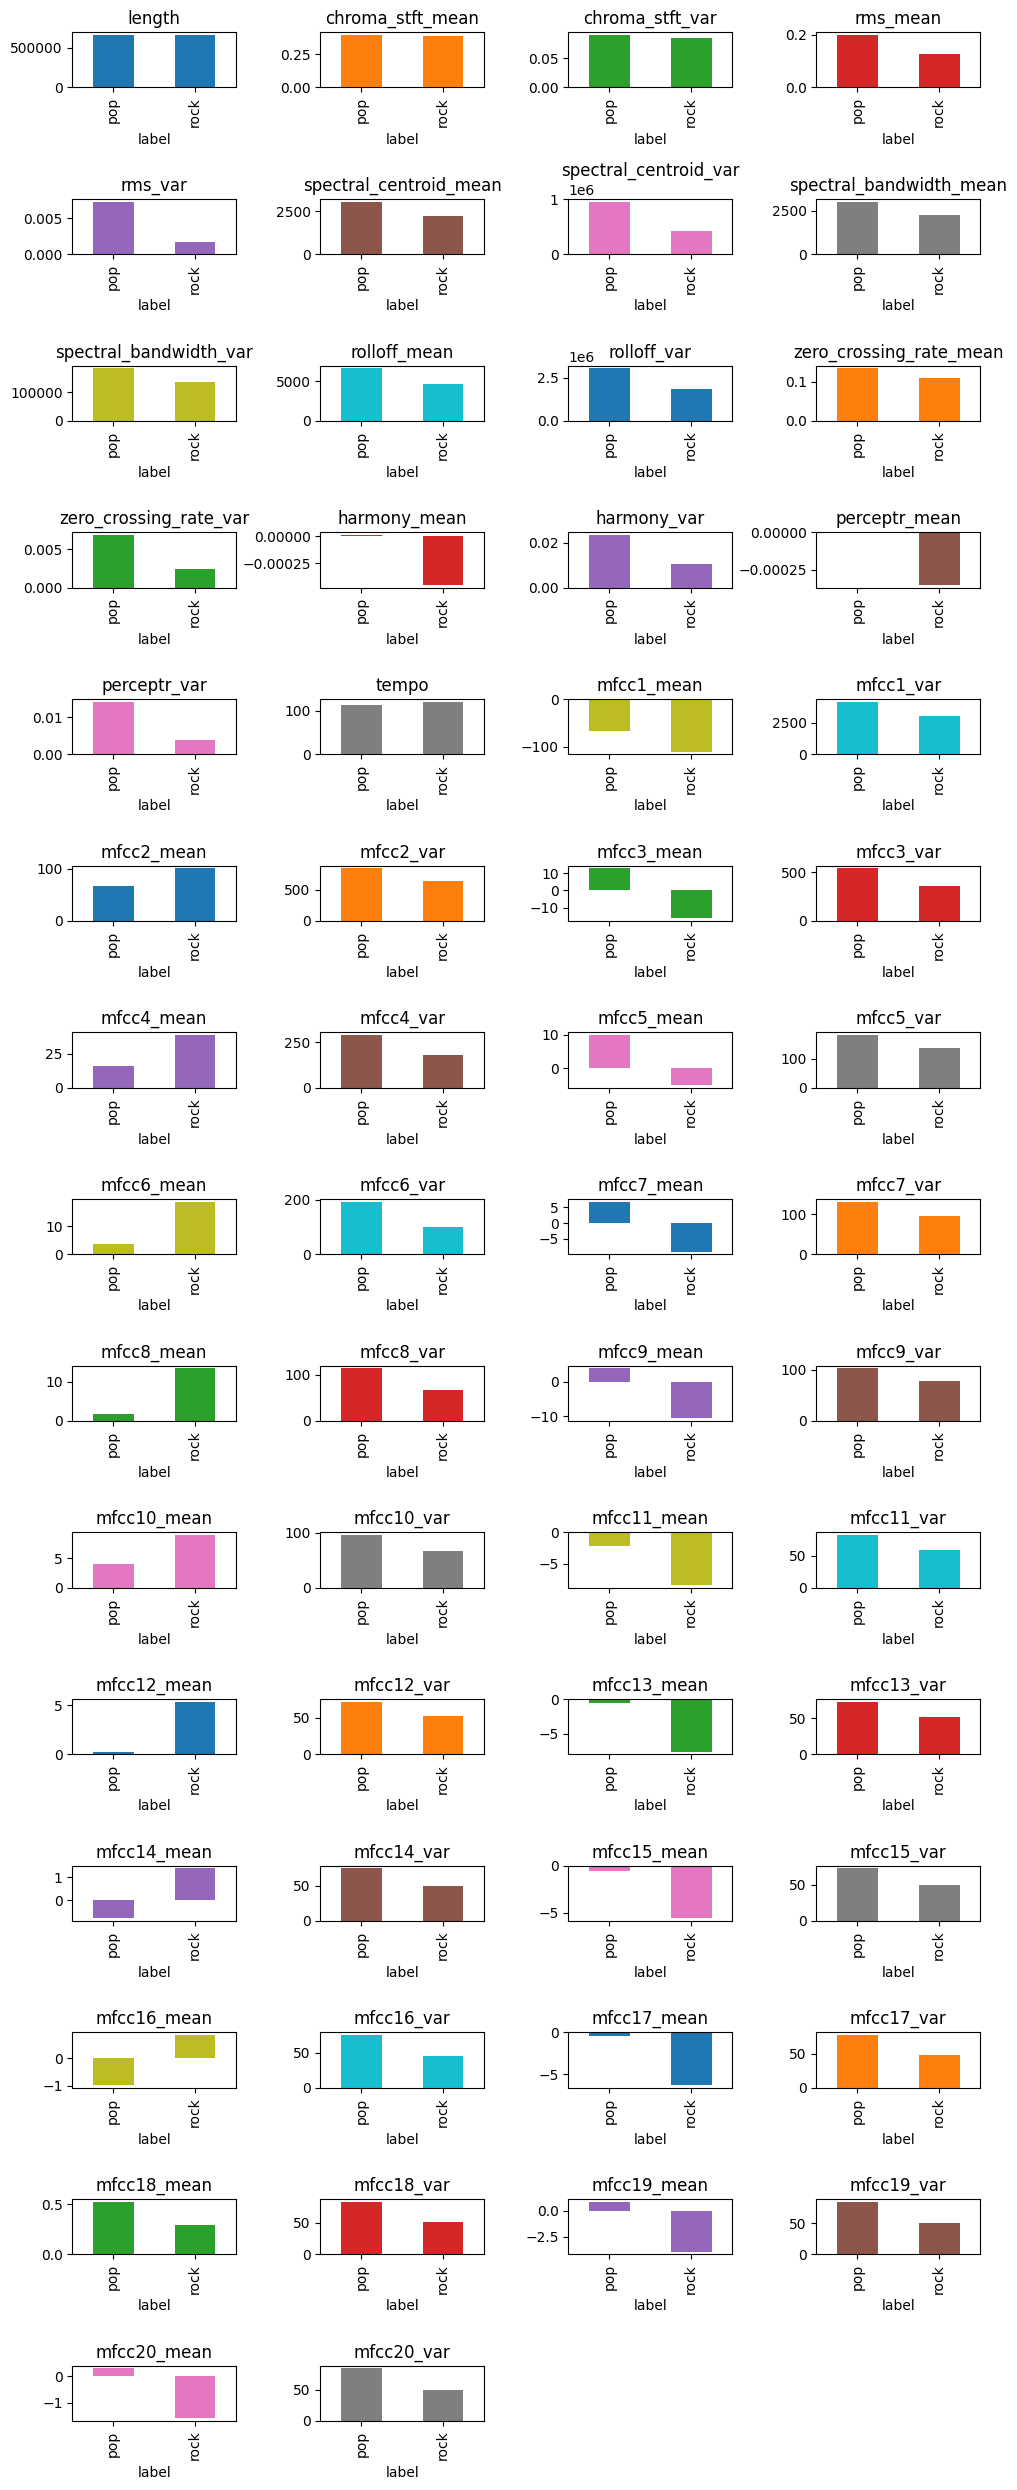

In [299]:
grouped = pd.DataFrame(df.groupby("label").mean(numeric_only=True))
cols = 4
rows = int(np.ceil(grouped.columns.size/cols))

# This took forever to figure out
grouped.plot.bar(figsize=(10, 25), subplots=True, layout=(rows, cols), sharex=False, xlabel=None, legend=False)
plt.tight_layout()

# From here, it looks like
# rms_mean/var, spectral_centroid_mean/var, harmony, perceptr, zcr_var, and the mfccs. of course these will have correlations.


### Define your feature matrix

Set your x and y based on your selected features and the label outcome.
Note: you will need to convert your 'label' column to 0 and 1. You can do so manually or with .get_dummies

In [300]:
label = pd.get_dummies(df["label"], drop_first=True)
label.head()

,rock
700,0
701,0
702,0
703,0
704,0


In [301]:
# rms_mean/var, spectral_centroid_mean/var, harmony, perceptr, zcr_var, and the mfccs. of course these will have correlations.
# feature_matrix = pd.concat([label, ], axis=1)
features = ["rms_var", "spectral_centroid_var", "perceptr_mean", "harmony_var", "zero_crossing_rate_mean"]
feature_matrix = df[features]
feature_matrix = pd.concat([label, feature_matrix], axis=1)
feature_matrix.head()

,rock,rms_var,spectral_centroid_var,perceptr_mean,harmony_var,zero_crossing_rate_mean
700,0,0.007513,1.080267e+06,-2.242359e-05,0.025329,0.126720
701,0,0.014924,1.404155e+06,-4.705784e-04,0.028870,0.149394
702,0,0.006579,1.006318e+06,5.181316e-05,0.022991,0.118866
703,0,0.001808,7.874765e+05,6.359164e-05,0.010407,0.085323
704,0,0.002561,7.178949e+05,-6.457002e-07,0.023408,0.123709


In [302]:
feature_matrix.corr()

,rock,rms_var,spectral_centroid_var,perceptr_mean,harmony_var,zero_crossing_rate_mean
rock,1.000000,-0.620690,-0.590769,-0.177760,-0.502252,-0.321961
rms_var,-0.620690,1.000000,0.636584,0.182618,0.654021,0.373682
spectral_centroid_var,-0.590769,0.636584,1.000000,0.135331,0.336395,0.253884
perceptr_mean,-0.177760,0.182618,0.135331,1.000000,0.160578,-0.069056
harmony_var,-0.502252,0.654021,0.336395,0.160578,1.000000,0.140737
zero_crossing_rate_mean,-0.321961,0.373682,0.253884,-0.069056,0.140737,1.000000


<AxesSubplot: >

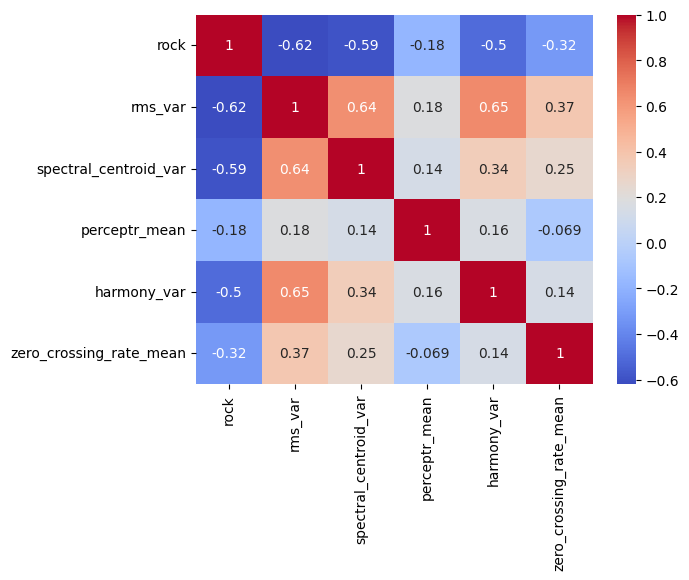

In [303]:
# I found this heatmap from online source because needed to see the labels to understand
# Some observations:
# 1. You really only need half the map to see the correlations as it is symmetric about the diagonal
# 2. I want to see high correlations between rock and my other variables b/c that means they are strong predictors
# 3. I want to avoid high correlations (I'll say > 0.6) of my "independent" variables b/c that indicates colinearity
# 4. This correlation matrix doesn't account for the possibility that 3+ features are linearly dependent even
# if the pairs do not correlate. Sources say I'd have to use VIF for that.
# https://quantifyinghealth.com/correlation-collinearity-multicollinearity/

sns.heatmap(feature_matrix.corr(), annot=True, cmap='coolwarm')
# With this in mind, I am going to switch out a few columns of feature matrix.

In [304]:
df.columns

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

<AxesSubplot: >

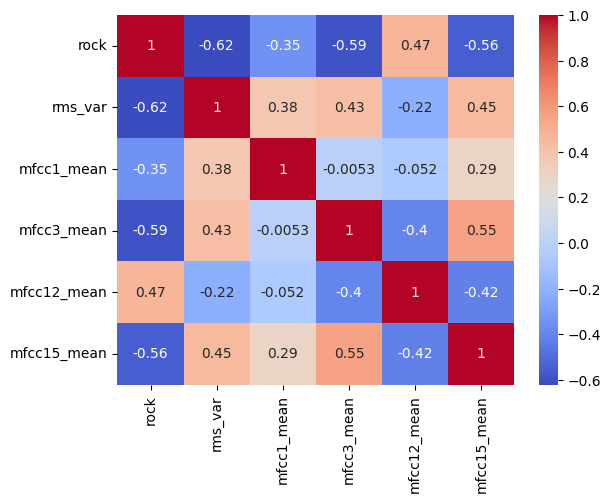

In [305]:
# Surprisingly, some of the mfccs have little correlation between others and they have high predictive power.
# That makes them very good for my feature matrix.
# I assume this is like comparing just the percepturally significant details
features = ["rms_var", "mfcc1_mean", "mfcc3_mean", "mfcc12_mean", "mfcc15_mean"]
feature_matrix = df[features]
feature_matrix = pd.concat([label, feature_matrix], axis=1)
sns.heatmap(feature_matrix.corr(), annot=True, cmap='coolwarm')

### Scale your feature matrix

Use StandardScaler to scale your feature matrix.

What would happen if you didn't scale?

- This is pretty clunky b/c the output of scaler.fit_transform has to be converted back to a dataframe
- It also should have been done earlier.
- If we didn't scale, features with a larger scale of values might unidominate the model


### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. For this activity, use 30% test size.

- By the way, there is an error in the lecture notes for lesson 15.
- The categories should actually be the predictors. You made the categories the features instead of the survived variable
- The code wasn't giving any errors because sklearn.train_test_split is smart and figures it out
- This confused me for a long time.

- predictor - X value. features
- category - Y value. genre classification
- train set - portion of data used to make predictions
- test set - data used to test prediction model using known Y_test as ground truth, and X_test as test of model

In [306]:
predictors, category = feature_matrix[features], feature_matrix.iloc[:,0]
# I'm going to rescale only the predictors, or else it might mess up my classification.
scaler = preprocessing.StandardScaler()
predictors = pd.DataFrame(scaler.fit_transform(predictors), columns=features)
print(predictors.head())
print(category.head())
# Note the final dataset is still not within unit variance.
# After looking into the function, it seems it is very sensitive to outliers.
# If I wanted to mitigate the skew on the dataset further, I would prune the outliers first.

    rms_var  mfcc1_mean  mfcc3_mean  mfcc12_mean  mfcc15_mean
0  0.669874   -0.088939    1.274839    -0.107886     0.339713
1  2.316930    0.494121    1.586629    -0.160085     0.687877
2  0.462414    0.487136    1.351349     0.267893     1.780258
3 -0.597919   -0.607074   -0.887913     0.200040     0.154440
4 -0.430677    1.125170    0.276007    -0.629342     0.466445
700    0
701    0
702    0
703    0
704    0
Name: rock, dtype: uint8


In [307]:
print((predictors.max()))

rms_var        3.805026
mfcc1_mean     1.872163
mfcc3_mean     2.264164
mfcc12_mean    2.233757
mfcc15_mean    2.344610
dtype: float64


In [308]:
pred_train, pred_test, cat_train, cat_test = train_test_split(predictors, category, test_size = .3, random_state=25)

### Train the Model

Train the model using logistic regression.

Take a look at your model's coefficients. What do they tell you about each feature's contribution to the model?

In [309]:
model = LogisticRegression() # lbfgs is default
model.fit(pred_train, cat_train)
coeffs = dict(zip(features, model.coef_[0]))
coeffs

{'rms_var': -1.9447669365935558,
 'mfcc1_mean': -0.42495490528297997,
 'mfcc3_mean': -0.9893862709441688,
 'mfcc12_mean': 0.6771874433944501,
 'mfcc15_mean': -0.31955793720664827}

Interpretation
- Increases in the rns_var are highly correlated with pop (not rock). This may mean that rock tends to keep a more constant energy
   throughout whereas pop is more varied.
- Each mfcc used except mfcc12 is also correlated with pop, but to a lesser extent.

### Evaluate

Calculate the confusion matrix (and view as a data frame).

What does the matrix tell you? What error type occurs most often?

In [310]:
predictions = model.predict(pred_test)
# specifying labels just in case. Don't want to misinterpret data
# It seems it's very easy to make a model that precisely guesses incorrectly
cm = confusion_matrix(cat_test, predictions, labels=[1,0])
# rows of cm are truth, columns are prediction
# This is another error in the lecture.
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
pd.DataFrame(cm, index=["rock", "pop"], columns=["predicted rock", "predicted pop"])

,predicted rock,predicted pop
rock,30,1
pop,6,23


Calculate the accuracy, precision, recall, and F1 scores.

What is your models accuracy?

In [311]:
# It's damn good.
# note that rock = positive, pop = negative
# FP : it was pop but it predicted rock
# FN : it was rock but it predicted pop
[TP, FN], [FP, TN] = cm
print(TP, TN, FP, FN)

30 23 6 1


In [312]:
accuracy = (TP + TN) / (TP + TN + FP + FN) * 100
precision = TP / (TP + FP) * 100
recall = TP / (TP + FN) * 100
print(f"accuracy: {accuracy}%")
print(f"precision: {precision}% The higher this is, the less likely you have a false positive for rock")
print(f"recall: {recall}% The higher this is, the more likely you got all the rock samples")

accuracy: 88.33333333333333%
precision: 83.33333333333334% The higher this is, the less likely you have a false positive for rock
recall: 96.7741935483871% The higher this is, the more likely you got all the rock samples


In [313]:
stop execution here

SyntaxError: invalid syntax (2836557997.py, line 1)

### Extension

Try again using a different feature set or try using the same feature set but with new genres. How does changing features impact your model? How do the same features apply to different genres?

## Extra Pandas practice

You will work with pandas dataframes a lot for Python MIR applications. Here are some more exercises to practice using the Pandas library.

### Practice with pandas Series and Dataframes

#### Making Data & Converting arrays to Series
Let's practice taking some `numpy` arrays and converting them to Series and Dataframe objects.

1. a) Make a numpy array from 2 to 20 with only even numbers.  
b) Make another numpy array from 1 to 19 with only odd numbers.  
c) Wrap each array in a pandas.Series() function to make it a Series object.  

In [ ]:
# Pause and try it

2. Use `np.vstack()` to combine (a) and (b) above into a multidimensional array 

In [ ]:
# stack 2 numpy arrays to 2d array

3. transpose the array (i.e., rotate so that columns become rows)

In [ ]:
# transpose array with the array object's transpose() method 

4. pass your 2d array to a pandas Dataframe function to create a dataframe. Give it a name and save it as a variable.

In [ ]:
# create dataframe

5. Name your columns. Call them "odd" and "even"

In [ ]:
# name the columns with the .columns() method (remember to make it a list!)

#### Read in existing data from a .csv file

Let's practice creating a `pandas` object directly through loading a .csv object. Let's open the file: "weather.csv" from the "Datasets" folder

In [ ]:
# load data with the `pandas.read_csv()` function.
import pandas as pd

df = pd.read_csv('../Datasets/weather.csv')

6. look at the uniqe list of city names from the city column with the `unique()` method

In [ ]:
# how many different cities in the dataframe

7. Count up how many data observations for each city (i.e., how many rows does each unique city name repeat?) Use the `value_counts()` method

In [ ]:
# what are the count values for each city?
df.head()

,Unnamed: 0,city,date,year,month,day,high_temp,avg_temp,low_temp,high_dewpt,...,avg_hg,low_hg,high_vis,avg_vis,low_vis,high_wind,avg_wind,low_wind,precip,events
0,1,Auckland,1/1/16,2016,1,1,68,65,62,64,...,30.09,30.01,6,6,4,21,15,28.0,0,Rain
1,2,Auckland,1/2/16,2016,1,2,68,66,64,64,...,29.90,29.80,6,5,1,33,21,46.0,0,Rain
2,3,Auckland,1/3/16,2016,1,3,77,72,66,70,...,29.73,29.68,6,6,1,18,12,NaN,0,Rain
3,4,Auckland,1/4/16,2016,1,4,73,66,60,66,...,29.90,29.77,6,6,6,15,10,NaN,0,Rain
4,5,Auckland,1/5/16,2016,1,5,69,62,55,55,...,30.14,30.09,6,6,6,13,7,NaN,0,NaN


8. Calculate the mean and standard deviation of the `avg_temp` column using the `.mean()` and `.std()` methods

In [ ]:
# 

#### Plotting

Basic plotting can be done right from your pandas dataframe object if you just want a simple graph:

| Plot Type       | Usage                            | Description / Example Use        |
|------------------|----------------------------------|-----------------------------------|
| **Line**         | `.plot()` or `.plot.line()`     | Default for time series / trends |
| **Bar**          | `.plot.bar()`                   | Vertical bar plot                |
| **Histogram**    | `.plot.hist()`                  | Distribution of values           |
| **Box**          | `.plot.box()`                   | Box-and-whisker plot             |
| **Scatter**      | `.plot.scatter(x='x', y='y')`   | Requires `x` and `y`             |


9. Make a line plot (across all data) with the high temp in red and the low temp in blue

Text(0.5, 1.0, 'High and Low Annual temperatures')

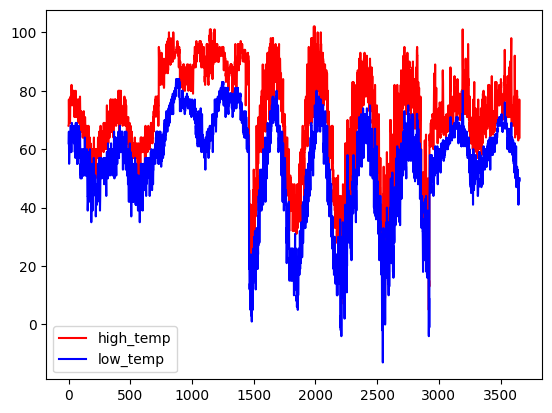

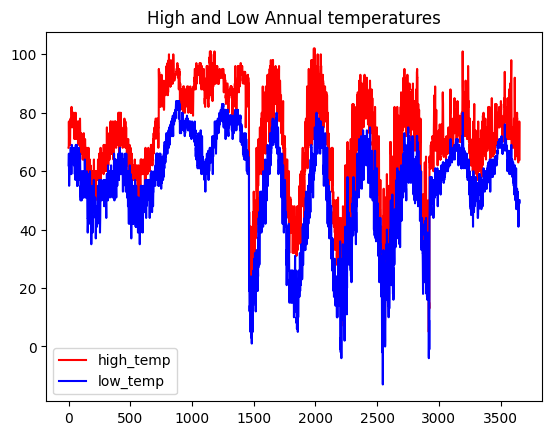

In [ ]:
# First, select only the two columns you care about:

subset = df[['high_temp', 'low_temp']]

# plot them with colors
subset.plot(color=['red', 'blue'])

# if you want to set a title, you have to save the plot as a variable ("ax" is common) and then apply a title, like this:

ax = subset.plot(color=['red', 'blue'])
ax.set_title("High and Low Annual temperatures")


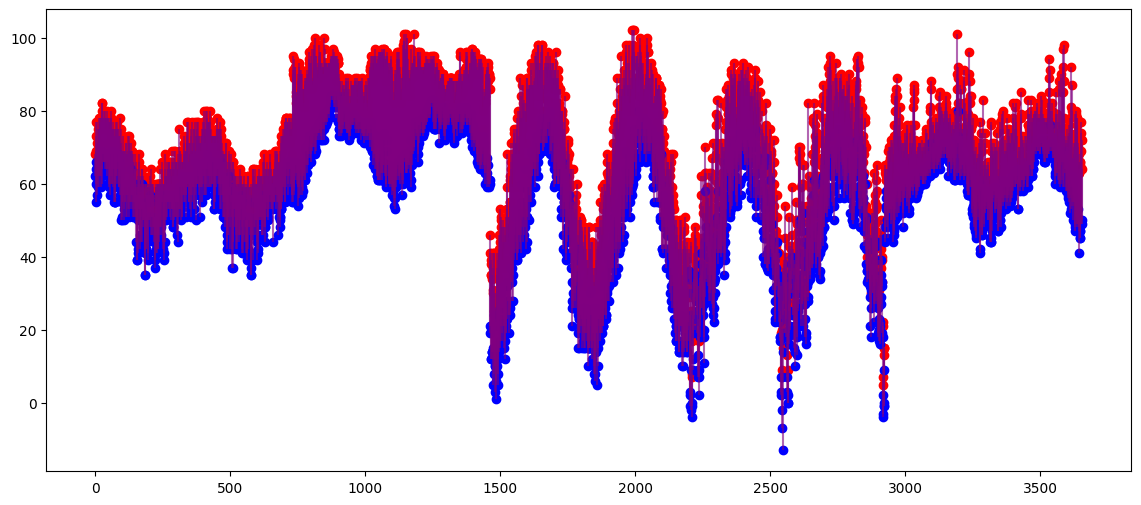

In [ ]:
# Let's instead try a "range" or "lolipop" plot where we plot the *distance* between the low and high temp for each row
# For more sophisticated plots like this we need matplotlib, we can simply pass the series directly to matplot library:
import matplotlib.pyplot as plt

# Plot the points (as before) with red and blue:
x = df.index # these are the row numbers!

# Set the figure size to widen it:
plt.figure(figsize = (14, 6))

plt.scatter(x, df['high_temp'], color='red', label='High Temp')
plt.scatter(x, df['low_temp'], color='blue', label='Low Temp')

# Next draw vertical lines between the points with `plt.vlines(x, y1, y2)`
plt.vlines(x, df['low_temp'], df['high_temp'], color='purple', alpha=0.6)


10. Make a new column of made up data to add to the weather dataframe. Let's call it "predicted_weather"
Using the values from the "events" column, let us randomly select values and put them in our new column. (You will not be making up data but you do need to know how to take a Series or array and "paste" it into an existing dataframe.

In [ ]:
df.events.unique() # note some are lists...

array(['Rain', nan, 'Fog , Rain , Thunderstorm', 'Fog , Rain',
       'Rain , Thunderstorm', 'Rain , Hail', 'Fog', 'Thunderstorm',
       'Rain , Hail , Thunderstorm', 'Snow', 'Rain , Snow',
       'Fog , Thunderstorm', 'Fog , Snow', 'Fog , Rain , Snow',
       'Fog , Snow , Thunderstorm'], dtype=object)

In [ ]:
# save a list variable returning some single events from the "events" column
unique_weather = ["Rain","Fog", "Hail", "Snow", "Thunderstorm"]

In [ ]:
# use numpy's `random.choice()` function to randomly select from your variable. 
import numpy as np
newcoldata = np.random.choice(unique_weather, size = len(df))

# add the newcoldata as a new column of data into your existing dataframe:
df['predicted_weather'] = newcoldata

11. Make a cross-tabulation (confusion matrix) for categorical variables using the `pd.crosstab()` function. Let us look at where our "events" matches our "predicted weather"

In [ ]:
# replace my variables with the appropriate column names to compute the cross tabulation
pd.crosstab(column1, column2)

NameError: name 'column1' is not defined